Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$ Run All).

In [1]:
NAME = "Sunny Kumar Tuladhar"

---

# Lab 03: Logistic Regression

Thus far, the problems we've encountered have been *regression* problems, in which the target $y \in \mathbb{R}$.

Today we'll start experimenting with *classification* problems, beginning with *binary* classification problems, in which the target $y \in \{ 0, 1 \}$.

## Background

The simplest approach to classification, applicable when the input feature vector $\mathbf{x} \in \mathbb{R}^n$, is a simple generalization of what we
do in linear regression. Recall that in linear regression, we assume that the target is drawn from a Gaussian distribution whose mean is a linear function
of $\mathbf{x}$:

$$ y \sim {\cal N}(\theta^\top \mathbf{x}, \sigma^2) $$

In logistic regression, similarly, we'll assume that the target is drawn from a Bernoulli distribution with parameter $p$ being the probability of
class 1:

$$ y \sim \text{Bernoulli}(p) $$

That's fine, but how do we model the parameter $p$? How is it related to $\mathbf{x}$?

In linear regression, we assume that the mean of the Gaussian is $\theta^\top \mathbf{x}$, i.e., a linear function of $\mathbf{x}$.

In logistic regression, we'll assume that $p$ is a "squashed" linear function of $\mathbf{x}$, i.e.,

$$ p = \text{sigmoid}(\theta^\top \mathbf{x}) = g(\theta^\top \mathbf{x}) = \frac{1}{1+e^{-\theta^\top \mathbf{x}}}. $$

Later, when we introduce generalized linear models, we'll see why $p$ should take this form. For now, though, we can simply note that the selection makes
sense. Since $p$ is a discrete probability, $p$ is bounded by $0 \le p \le 1$. The sigmoid function $g(\cdot)$ conveniently obeys these bounds:


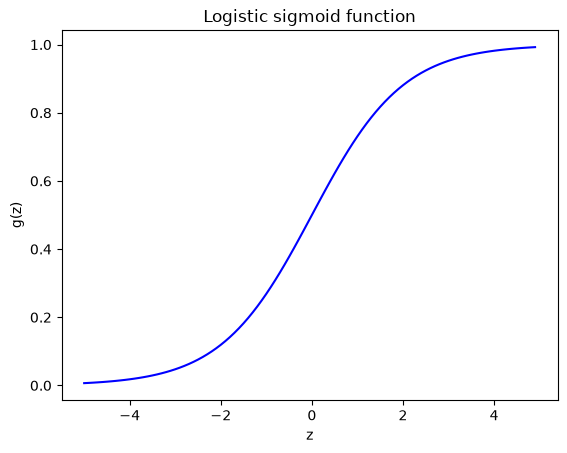

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f(z):
 return 1 / (1 + np.exp( -z ))

z = np.arange(-5, 5, 0.1)
plt.plot(z, f(z), 'b-')
plt.xlabel('z')
plt.ylabel('g(z)')
plt.title('Logistic sigmoid function')
plt.show()

We see that the sigmoid approaches 0 as its input approaches $-\infty$ and approaches 1 as its input approaches $+\infty$. If its input is 0, its value is 0.5.

Again, this choice of function may seem strange at this , but bear with it! We'll derive this function from a more general principle, the generalized
linear model, later.

OK then, we now understand that for logistic regression, the assumptions are:

1. The *data* are pairs $(\textbf{x}, y) \in \mathbb{R}^n \times \{ 0, 1 \}$.
1. The *hypothesis function* is $h_\theta(\textbf{x}) = \frac{1}{1+e^{-\theta^\top \mathbf{x}}}$.

What else do we need... ? A cost function and an algorithm for minimizing that cost function!

## Cost function for logistic regression

You can refer to the to see the derivation, but for this lab, let's just skip to the chase.
With the hypothesis $h_\theta(\mathbf{x})$ chosen as above, the log likelihood function $\ell(\theta)$ can be derived as
$$ \ell(\theta) = \log {\cal L}(\theta) = \sum_{i=1}^{m}y^{(i)}\log(h_{\theta}(\mathbf{x}^{(i)})) + (1 - y^{(i)})\log(1 - (h_{\theta}(\mathbf{x}^{(i)})) .$$

Negating the log likelihood function to obtain a loss function, we have

$$ J(\theta) = - \sum_{i=1}^m y^{(i)}\log h_\theta(\mathbf{x}^{(i)}) + (1-y^{(i)})\log(1-h_\theta(\textbf{x}^{(i)})) .$$

There is no closed-form solution to this problem like there is in linear regression, so we have to use gradient descent to find $\theta$ minimizing $J(\theta)$.
Luckily, the function *is* convex in $\theta$ so there is just a single global minimum, and gradient descent is guaranteed to get us there eventually if we take
the right step size.

The *stochastic* gradient of $J$, for a single observed pair $(\mathbf{x}, y)$, turns out to be (see )

$$\nabla_J(\theta) = (h_\theta(\mathbf{x}) - y)\mathbf{x} .$$

Give some thought as to whether following this gradient to increase the loss $J$ would make a worse classifier, and vice versa!

Finally, we obtain the update rule for the $j$ th iteration selecting training pattern $i$:

$$\boldsymbol{\theta}^{(t+1)} \leftarrow \boldsymbol{\theta}^{(t)} + \alpha \left( y^{(i)} - h_{\boldsymbol{\theta}}(\mathbf{x}^{(i)}) \right) \mathbf{x}^{(i)}$$

Note that we can perform *batch gradient descent* simply by summing the single-pair gradient over the entire training set before taking a step,
or *mini-batch gradient descent* by summing over a small subset of the data.

## Example dataset 1: student admissions data

This example is from Andrew Ng's machine learning course on Coursera.

The data contain students' scores for two standardized tests and an admission decision (0 or 1).


In [4]:

# Load student admissions data. The data file does not contain headers,
# so we use hard coded indices for exam 1, exam2, and the admission decision.

data = np.loadtxt('ex2data1.txt',delimiter = ',')
exam1_data = data[:,0]
exam2_data = data[:,1]
X = np.array([exam1_data, exam2_data]).T
y = data[:,2]

# Output some sample data

print('Exam scores', X[0:5,:])
print('-----------------------------')
print('Admission decision', y[0:5])


Exam scores [[34.62365962 78.02469282]
 [30.28671077 43.89499752]
 [35.84740877 72.90219803]
 [60.18259939 86.3085521 ]
 [79.03273605 75.34437644]]
-----------------------------
Admission decision [0. 0. 0. 1. 1.]


Let's plot the data...

In [5]:
y.shape

(100,)

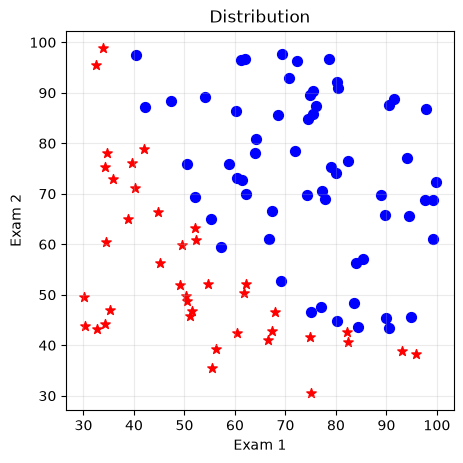

In [6]:
# Plot the data

idx_0 = np.where(y == 0)
idx_1 = np.where(y == 1)

fig1 = plt.figure(figsize=(5, 5)) 
ax = plt.axes()
ax.set_aspect(aspect = 'equal', adjustable = 'box')
plt.title('Distribution')
plt.xlabel('Exam 1')
plt.ylabel('Exam 2')
plt.grid(axis='both', alpha=.25)
ax.scatter(exam1_data[idx_0], exam2_data[idx_0], s=50, c='r', marker='*', label='Not Admitted')
ax.scatter(exam1_data[idx_1], exam2_data[idx_1], s=50, c='b', marker='o', label='Admitted')
plt.show()


Let's see if we can find good values for $\theta$ without normalizing the data.
We will definitely want to split the data into train and test, however...

In [7]:
import random

# As usual, we fix the seed to eliminate random differences between different runs

random.seed(12)

# Partion data into training and test datasets

m, n = X.shape
XX = np.insert(X, 0, 1, axis=1)
y = y.reshape(m, 1)
idx = np.arange(0, m)
random.shuffle(idx)
percent_train = .6
m_train = int(m * percent_train)
train_idx = idx[0:m_train]
test_idx = idx[m_train:]
X_train = XX[train_idx,:];
X_test = XX[test_idx,:];

y_train = y[train_idx];
y_test = y[test_idx];

### Important functions needed later

Let's put all of our important functions here...

In [8]:
def sigmoid(z): 
 return 1 / (1 + np.exp(-z))

def h(X, theta):
 return sigmoid(X @ theta)

def grad_j(X, y, y_pred):
 return X.T @ (y - y_pred) / X.shape[0]
 
def j(theta, X, y): 
 y_pred = h(X, theta)
 error = (-y * np.log(y_pred)) - ((1 - y) * np.log(1 - y_pred))
 cost = sum(error) / X.shape[0]
 grad = grad_j(X, y, y_pred)
 return cost[0], grad


### Initialize theta

In any iterative algorithm, we need an initial guess. Here we'll just use zeros for all parameters.

In [9]:
# Initialize our parameters, and use them to make some predictions

theta_initial = np.zeros((n+1, 1))

print('Initial theta:', theta_initial)
print('Initial predictions:', h(XX, theta_initial)[0:5,:])
print('Targets:', y[0:5,:])


Initial theta: [[0.]
 [0.]
 [0.]]
Initial predictions: [[0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]]
Targets: [[0.]
 [0.]
 [0.]
 [1.]
 [1.]]


### Training function

Here's a function to do batch training for `num_iters` iterations.

In [11]:
def train(X, y, theta_initial, alpha, num_iters):
    theta = theta_initial
    j_history = []
    for i in range(num_iters):
        cost, grad = j(theta, X, y)
        theta = theta + alpha * grad
        j_history.append(cost)
    return theta, j_history


### Do the training

Here we run the training function for a million batches!

In [12]:
# Train for 1000000 iterations on full training set

alpha = .0005
num_iters = 1000000
theta, j_history = train(X_train, y_train, theta_initial, alpha, num_iters)

print("Theta optimized:", theta)
print("Cost with optimized theta:", j_history[-1])

Theta optimized: [[-11.29380461]
 [  0.10678604]
 [  0.07994591]]
Cost with optimized theta: 0.24972975869900044


### Plot the loss curve

Next let's plot the loss curve (loss as a function of iteration).

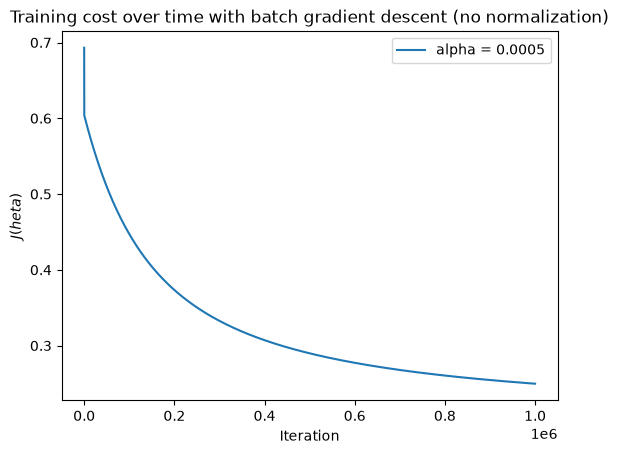

In [13]:
plt.plot(j_history)
plt.xlabel("Iteration")
plt.ylabel("$J(\theta)$")
plt.title("Training cost over time with batch gradient descent (no normalization)")
plt.legend(['alpha = 0.0005'])
plt.show()



### In-lab exercise from Example 1

That took a long time, right?

We'll see if we can do better. We will try the following:

1. Try increasing the learning rate $\alpha$ and starting with a better initial $\theta$. How much does it help?
 - Try at least 2 learning rate $\alpha$ with 2 difference $\theta$ (4 experiments)
 - Do not forget to plot the loss curve to compare your results

2. Better yet, try *normalizing the data* and see if the training converges better. How did it go? 
 - Be sure to plot loss curves to compare the results with unnormalized and normalized data.

3. Discuss the effects of normalization, learning rate, and initial $\theta$ in your report.

Do this work in the following steps.


### Exercise 1.1

Fill in two different values for $\alpha$ and $\theta$.

Use variable names `alpha1`, `alpha2`, `theta_initial1`, and `theta_initial2`.

In [15]:
# grade task: change 'None' value to number(s) or function
# YOUR CODE HERE
#raise NotImplementedError()
# declare your alphas
alpha1 = .0008
alpha2 = .0006

#initialize thetas as you want
theta_initial1 = np.array([100, 100, 12]).reshape(-1,1)
theta_initial2 = np.array([0, 0, 0]).reshape(-1,1)

# define your num iterations
num_iters = 100000

In [16]:
theta_initial1.shape

(3, 1)

In [17]:
alpha_list = [alpha1, alpha2]
print('alpha 1:', alpha1)
print('alpha 2:', alpha2)

theta_initial_list = [theta_initial1, theta_initial2]
print('theta 1:', theta_initial_list[0])
print('theta 2:', theta_initial_list[1])

print('Use num iterations:', num_iters)

# Test function: Do not remove
assert alpha_list[0] is not None and alpha_list[1] is not None, "Alpha has not been filled"
chk1 = isinstance(alpha_list[0], (int, float))
chk2 = isinstance(alpha_list[1], (int, float))
assert chk1 and chk2, "Alpha must be number"
assert theta_initial_list[0] is not None and theta_initial_list[1] is not None, "initialized theta has not been filled"
chk1 = isinstance(theta_initial_list[0], (list,np.ndarray))
chk2 = isinstance(theta_initial_list[1], (list,np.ndarray))
assert chk1 and chk2, "Theta must be list"
chk1 = ((n+1, 1) == theta_initial_list[0].shape)
chk2 = ((n+1, 1) == theta_initial_list[1].shape)
assert chk1 and chk2, "Theta size are incorrect"
assert num_iters is not None and isinstance(num_iters, int), "num_iters must be integer"
print("success!")
# End Test function

alpha 1: 0.0008
alpha 2: 0.0006
theta 1: [[100]
 [100]
 [ 12]]
theta 2: [[0]
 [0]
 [0]]
Use num iterations: 100000
success!


### Exercise 1.2

Fill in the code required to train your model on a particular $\alpha$ and $\theta$:

In [19]:
# grade task: change 'None, None' value to number(s) or function
j_history_list = []
theta_list = []
for alpha in alpha_list:
    for theta_initial in theta_initial_list:
        # YOUR CODE HERE
        #raise NotImplementedError()
        theta_i, j_history_i = train(X_train, y_train, theta_initial, alpha, num_iters)
        j_history_list.append(j_history_i)
        theta_list.append(theta_i)

C:\Users\USER\AppData\Local\Temp\ipykernel_20344\133261558.py:12: RuntimeWarning: divide by zero encountered in log
  error = (-y * np.log(y_pred)) - ((1 - y) * np.log(1 - y_pred))
C:\Users\USER\AppData\Local\Temp\ipykernel_20344\133261558.py:12: RuntimeWarning: invalid value encountered in multiply
  error = (-y * np.log(y_pred)) - ((1 - y) * np.log(1 - y_pred))
C:\Users\USER\AppData\Local\Temp\ipykernel_20344\133261558.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


In [20]:
# Test function: Do not remove
assert theta_list[0] is not None and j_history_list[0] is not None, "No values in theta_list or j_history_list"
chk1 = isinstance(theta_list[0], (list,np.ndarray))
chk2 = isinstance(j_history_list[0][0], (int, float))
assert chk1 and chk2, "Wrong type in theta_list or j_history_list"
print("success!")
# End Test function

success!


### Exercise 1.3

Write code to plot loss curves for each of the sequences in `j_history_list` from the previous exercise:

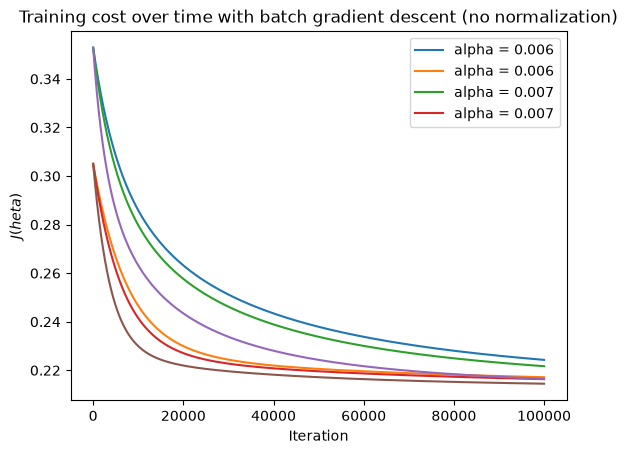

In [37]:
# YOUR CODE HERE
for i in j_history_list:
 plt.plot(i)
 
plt.xlabel("Iteration")
plt.ylabel("$J(\theta)$")
plt.title("Training cost over time with batch gradient descent (no normalization)")
plt.legend(['alpha = 0.006','alpha = 0.006','alpha = 0.007','alpha = 0.007'])
plt.show()
#raise NotImplementedError()

In [38]:
print(np.mean(X, axis=0))
print(np.std(X, axis=0))

[65.64427406 66.22199809]
[19.36068671 18.48963567]


### Exercise 1.4

- Repeat your training, but **normalize** your data before training
- Compare the results between normalized data and unnormalized data

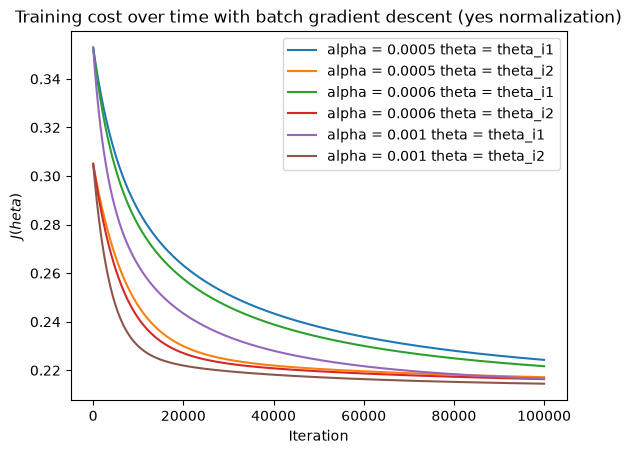

In [39]:
# code here
def normalized_data(data):
 means = np.mean(data, axis=0) #calculate the mean
 stds = np.std(data, axis=0) #calculate the std 
 data_norm = (data - means) / stds
 return data_norm


X_norm = normalized_data(X)
X_intercept = np.insert(X_norm, 0, 1, axis=1)

X_train = X_intercept[train_idx,:]
X_test = X_intercept[test_idx,:]

alpha1 = .0005
alpha2 = .0006
alpha3 = .001

#initialize thetas as you want
theta_initial1 = np.array([1,1,1]).reshape(-1,1)
theta_initial2 = np.array([2, 2, 2]).reshape(-1,1)

# define your num iterations
num_iters = 100000
theta_initial_list = [theta_initial1, theta_initial2]
alpha_list = [alpha1, alpha2, alpha3]

j_history_list = []
theta_list = []
for alpha in alpha_list:
    for theta_initial in theta_initial_list:
        # YOUR CODE HERE
        #raise NotImplementedError()
        theta_i, j_history_i = train(X_train, y_train, theta_initial, alpha, num_iters)
        j_history_list.append(j_history_i)
        theta_list.append(theta_i)
 

for i in j_history_list:
 plt.plot(i)
 
plt.xlabel("Iteration")
plt.ylabel("$J(\theta)$")
plt.title("Training cost over time with batch gradient descent (yes normalization)")
plt.legend(['alpha = ' + str(alpha1) + ' theta = theta_i1',
 'alpha = ' + str(alpha1) + ' theta = theta_i2',
 'alpha = ' + str(alpha2) + ' theta = theta_i1',
 'alpha = ' + str(alpha2) + ' theta = theta_i2',
 'alpha = ' + str(alpha3) + ' theta = theta_i1',
 'alpha = ' + str(alpha3) + ' theta = theta_i2'])
plt.show()
#raise NotImplementedError() 

### Exercise 1.5

Discuss the effects of normalization, learning rate, and initial $\theta$ in your report.

Write your discussion here.

### Answer
A higher learning rate makes the loss converge faster but upto a certain .
Normalisation also helps to converge faster as we reach a much lower loss at the same learning rate and iteration.The curve is also smoother.

Initial theta does not seem to have much influence over the loss function in the long run. But for short iterations initialisation to ones seems to yield a lower loss.


### The logistic regression decision boundary

Note that when $\theta^\top \textbf{x} = 0$, we have $h_\theta(\textbf{x}) = 0.5$. That is, we are
equally unsure as to whether $\textbf{x}$ belongs to class 0 or class 1. The contour at which
$h_\theta(\textbf{x}) = 0.5$ is called the classifier's *decision boundary*.

We know that in the plane, the equation $$ax+by+c=0$$ is the general form of a 2D line. In our case, we have
$$\boldsymbol{\theta}^\top \mathbf{x} = 0$$

as our decision boundary, but clearly, this is just a 2D line
in the plane. So when we plot $x_1$ against $x_2$, it is easy to plot the boundary line.

In [40]:
def boundary_points(X, theta):
 v_orthogonal = np.array([[theta[1,0]],[theta[2,0]]])
 v_ortho_length = np.sqrt(v_orthogonal.T @ v_orthogonal)
 dist_ortho = theta[0,0] / v_ortho_length
 v_orthogonal = v_orthogonal / v_ortho_length
 v_parallel = np.array([[-v_orthogonal[1,0]],[v_orthogonal[0,0]]])
 projections = X @ v_parallel
 proj_1 = min(projections)
 proj_2 = max(projections)
 point_1 = proj_1 * v_parallel - dist_ortho * v_orthogonal
 point_2 = proj_2 * v_parallel - dist_ortho * v_orthogonal
 return point_1, point_2

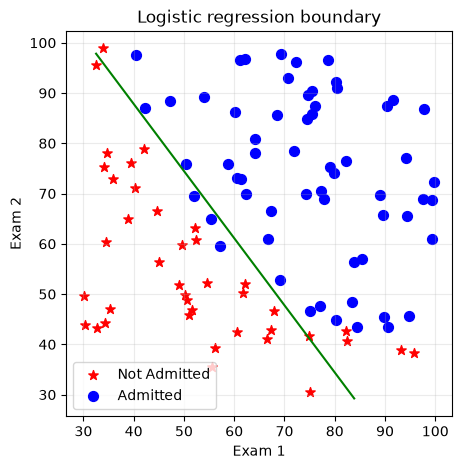

In [41]:
fig1 = plt.figure(figsize=(5,5)) 
ax = plt.axes() 
ax.set_aspect(aspect = 'equal', adjustable = 'box')
plt.title('Logistic regression boundary')
plt.xlabel('Exam 1')
plt.ylabel('Exam 2')
plt.grid(axis='both', alpha=.25)
ax.scatter(X[:,0][idx_0], X[:,1][idx_0], s=50, c='r', marker='*', label='Not Admitted')
ax.scatter(X[:,0][idx_1], X[:,1][idx_1], s=50, c='b', marker='o', label='Admitted')
point_1, point_2 = boundary_points(X, theta)
plt.plot([point_1[0,0], point_2[0,0]],[point_1[1,0], point_2[1,0]], 'g-')
plt.legend(loc=0)
plt.show()


You may have to adjust the above code to make it work with normalized data.

### Test set performance

Now let's apply the learned classifier to the test data we reserved in the beginning:


In [42]:
def r_squared(y, y_pred):
 return 1 - np.square(y - y_pred).sum() / np.square(y - y.mean()).sum()

In [43]:
y_test_pred_soft = h(X_test, theta)
y_test_pred_hard = (y_test_pred_soft > 0.5).astype(int)

test_rsq_soft = r_squared(y_test, y_test_pred_soft)
test_rsq_hard = r_squared(y_test, y_test_pred_hard)
test_acc = (y_test_pred_hard == y_test).astype(int).sum() / y_test.shape[0]

print('Got test set soft R^2 %0.4f, hard R^2 %0.4f, accuracy %0.2f' % (test_rsq_soft, test_rsq_hard, test_acc))

Got test set soft R^2 -1.3529, hard R^2 -1.3529, accuracy 0.42


For classification, accuracy is probably the more useful measure of goodness of fit.

## Example 2: Loan prediction dataset

Let's take another example dataset and see what we can do with it.

This dataset is from [Kaggle](https://www.kaggle.com/altruistdelhite04/loan-prediction-problem-dataset).

The data concern loan applications. It has 12 independent variables, including 5 categorical variables. The dependent variable is the decision "Yes" or "No" for extending a loan to an individual who applied.

One thing we will have to do is to clean the data, by filling in missing values and converting categorical data to reals.
We will use the Python libraries pandas and sklearn to help with the data cleaning and preparation.

### Read the data and take a look at it

In [44]:
# !pip install pandas

In [45]:
# Import Pandas. You may need to run "pip3 install pandas" at the console if it's not already installed

import pandas as pd

# Import the data

data_train = pd.read_csv('train_LoanPrediction.csv')
data_test = pd.read_csv('test_LoanPrediction.csv')

# Start to explore the data

print('Training data shape', data_train.shape)
print('Test data shape', data_test.shape)

print('Training data:\n', data_train)


Training data shape (614, 13)
Test data shape (367, 12)
Training data:
       Loan_ID  Gender Married Dependents     Education Self_Employed  \
0    LP001002    Male      No          0      Graduate            No   
1    LP001003    Male     Yes          1      Graduate            No   
2    LP001005    Male     Yes          0      Graduate           Yes   
3    LP001006    Male     Yes          0  Not Graduate            No   
4    LP001008    Male      No          0      Graduate            No   
..        ...     ...     ...        ...           ...           ...   
609  LP002978  Female      No          0      Graduate            No   
610  LP002979    Male     Yes         3+      Graduate            No   
611  LP002983    Male     Yes          1      Graduate            No   
612  LP002984    Male     Yes          2      Graduate            No   
613  LP002990  Female      No          0      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amoun

In [46]:
# Check for missing values in the training and test data

print('Missing values for train data:\n------------------------\n', data_train.isnull().sum())
print('Missing values for test data \n ------------------------\n', data_test.isnull().sum())

Missing values for train data:
------------------------
 Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64
Missing values for test data 
 ------------------------
 Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64


### Handle missing values

We can see from the above table that the `Married` column has 3 missing values in the training dataset and 0 missing values in the test dataset.
Let's take a look at the distribution over the datasets then fill in the missing values in approximately the same ratio.

You may be interested to look at the [documentation of the Pandas `fillna()` function](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.fillna.html). It's great!

In [47]:
import numpy as np
import pandas as pd

# 1. Print current counts and missing values before filling
print("--- BEFORE FILLING ---")
print("Value Counts:\n", data_train['Married'].value_counts(dropna=False))
print("Missing 'Married' count:", data_train['Married'].isnull().sum())
print("-" * 35)

# 2. Compute category proportions/ratios (excluding NaNs)
married_counts = data_train['Married'].value_counts()

# Use .iloc[0] or ['Yes'] to safely access series values by position or label
yes_ratio = married_counts['Yes'] / married_counts.sum()
no_ratio = married_counts['No'] / married_counts.sum()

print(f"Yes Ratio: {yes_ratio:.4f}")
print(f"No Ratio:  {no_ratio:.4f}")

# 3. Calculate how many NaNs to assign to each category based on ratio
total_missing = data_train['Married'].isnull().sum()
yes_missing_to_fill = int(np.round(total_missing * yes_ratio))
no_missing_to_fill = total_missing - yes_missing_to_fill  # Remaining goes to 'No'

print(f"\nFilling {yes_missing_to_fill} missing with 'Yes' and {no_missing_to_fill} with 'No'.")


# 4. Fill missing values sequentially using pandas limit
def fill_marital_status(df, fill_yes_count, fill_no_count):
    # Modern pandas syntax (assign back instead of inplace=True)
    if fill_yes_count > 0:
        df['Married'] = df['Married'].fillna('Yes', limit=fill_yes_count)
    if fill_no_count > 0:
        df['Married'] = df['Married'].fillna('No', limit=fill_no_count)


fill_marital_status(data_train, yes_missing_to_fill, no_missing_to_fill)

# 5. Print values after filling for confirmation
print("\n--- AFTER FILLING ---")
print("Value Counts:\n", data_train['Married'].value_counts(dropna=False))
print("Remaining missing 'Married' count:", data_train['Married'].isnull().sum())

--- BEFORE FILLING ---
Value Counts:
 Married
Yes    398
No     213
NaN      3
Name: count, dtype: int64
Missing 'Married' count: 3
-----------------------------------
Yes Ratio: 0.6514
No Ratio:  0.3486

Filling 2 missing with 'Yes' and 1 with 'No'.

--- AFTER FILLING ---
Value Counts:
 Married
Yes    400
No     214
Name: count, dtype: int64
Remaining missing 'Married' count: 0


Now the number of examples missing the `Married` attribute is 0.

Let's complete the data processing based on examples given and logistic regression model on training dataset. Then we'll get the model's accuracy (goodness of fit) on the test dataset.

Here is another example of filling in missing values for the `Dependents` (number of children and other dependents)
attribute. We see that categorical values are all numeric except one value "3+"
Let's create a new category value "4" for "3+" and ensure that all the data is numeric:

In [48]:
import numpy as np
import pandas as pd

# 1. Print existing value counts
print(data_train['Dependents'].value_counts())
dependent = data_train['Dependents'].value_counts()

# 2. Compute category ratios safely
total_count = dependent.sum()
print('Dependent ratio 0: ', dependent['0'] / total_count)
print('Dependent ratio 1: ', dependent['1'] / total_count)
print('Dependent ratio 2: ', dependent['2'] / total_count)
print('Dependent ratio 3+: ', dependent['3+'] / total_count)

# 3. Fill missing values without `inplace=True` or chained assignment
def fill_dependent_status(num_0_tr, num_1_tr, num_2_tr, num_3_tr, 
                          num_0_te, num_1_te, num_2_te, num_3_te): 
    # Fill data_train sequentially
    if num_0_tr > 0:
        data_train['Dependents'] = data_train['Dependents'].fillna('0', limit=num_0_tr)
    if num_1_tr > 0:
        data_train['Dependents'] = data_train['Dependents'].fillna('1', limit=num_1_tr)
    if num_2_tr > 0:
        data_train['Dependents'] = data_train['Dependents'].fillna('2', limit=num_2_tr)
    if num_3_tr > 0:
        data_train['Dependents'] = data_train['Dependents'].fillna('3+', limit=num_3_tr)

    # Fill data_test sequentially
    if num_0_te > 0:
        data_test['Dependents'] = data_test['Dependents'].fillna('0', limit=num_0_te)
    if num_1_te > 0:
        data_test['Dependents'] = data_test['Dependents'].fillna('1', limit=num_1_te)
    if num_2_te > 0:
        data_test['Dependents'] = data_test['Dependents'].fillna('2', limit=num_2_te)
    if num_3_te > 0:
        data_test['Dependents'] = data_test['Dependents'].fillna('3+', limit=num_3_te)

# Execute function
fill_dependent_status(9, 2, 2, 2, 5, 2, 2, 1)

print(data_train['Dependents'].value_counts())

# 4. Convert category value "3+" to 4 (assigning back instead of inplace=True)
data_train['Dependents'] = data_train['Dependents'].replace('3+', 4)
data_test['Dependents'] = data_test['Dependents'].replace('3+', 4)

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64
Dependent ratio 0:  0.5759599332220368
Dependent ratio 1:  0.17028380634390652
Dependent ratio 2:  0.1686143572621035
Dependent ratio 3+:  0.08514190317195326
Dependents
0     354
1     104
2     103
3+     53
Name: count, dtype: int64


Once missing values are filled in, you'll want to convert strings to numbers.

Finally, here's an example of replacing missing values for a numeric attribute. Typically, we would use the mean of the attribute over the training set. 

In [51]:
import numpy as np

# 1. Inspect value counts and mean
print(data_train['LoanAmount'].value_counts())
loan_amt = data_train['LoanAmount'].value_counts()

loan_amount_mean = data_train['LoanAmount'].mean()
print('mean loan amount ', loan_amount_mean)

# 2. Fill missing values by direct assignment (replaces inplace=True)
data_train['LoanAmount'] = data_train['LoanAmount'].fillna(loan_amount_mean, limit=22)
data_test['LoanAmount'] = data_test['LoanAmount'].fillna(loan_amount_mean, limit=5)

LoanAmount
120.0    20
110.0    17
100.0    15
187.0    12
160.0    12
         ..
292.0     1
142.0     1
350.0     1
496.0     1
253.0     1
Name: count, Length: 203, dtype: int64
mean loan amount  146.41216216216216


## Take-home exercise

Using the data from Example 2 above, finish the data cleaning and
preparation. Build a logistic regression model based on the
cleaned dataset and report the accuracy on the test and training sets.

- Set up $\mathbf{x}$ and $y$ data (10 )
- Train a logistic regression model and return the values of $\theta$ and $J$ you obtained. Find the best $\alpha$ you can; you may find it best to normalize before training. (30 )
- Using the best model parameters $\theta$ you can find, run on the test set and get the model's accuracy. (10 )
- Summarize what you did to find the best results in this take home exercise. (15 )

## To turn in

Turn in this Jupyter notebook with your solutions to he exercises and your experiment reports,
both for the in-lab exercise and the take-home exercise. Be sure you've discussed what
you learned in terms of normalization and data cleaning and the results
you obtained.


In [28]:
data_train.isnull().sum() 

Loan_ID 0
Gender 13
Married 0
Dependents 0
Education 0
Self_Employed 32
ApplicantIncome 0
CoapplicantIncome 0
LoanAmount 0
Loan_Amount_Term 14
Credit_History 50
Property_Area 0
Loan_Status 0
dtype: int64